In [ ]:
from qubosolver import SolverConfig

import warnings
import logging
from qubosolver.utils._random import register_seeded_magic

warnings.filterwarnings("ignore", module="matplotlib")
logging.getLogger("emulators").addFilter(lambda record: record.levelno >= logging.ERROR)
register_seeded_magic()

%matplotlib inline

## Embeddings

When using quantum approaches, we have to define a map from the instance variables to atoms on a quantum device. We call this step an embedding. This tutorial aims to show small code snippet on how to use the different embedding methods (`blade`, `custom`, `greedy`) as well as how to parametrize the algorithms through the `SolverConfig` according to a given QUBO matrix. 

   labels       bitstrings       costs  counts  probs
0       0  100101100000010 -205.649830       1  0.001
1       0  100000100000010 -199.302937       2  0.002
2       0  100000110000010 -178.590227       1  0.001
3       0  100001100000000 -177.514687       2  0.002
4       0  100000100001000 -175.325455       2  0.002
5       0  100000000001010 -169.498798       3  0.003
6       0  100100100000010 -167.246616       1  0.001
7       0  000001100000010 -164.612797       1  0.001
8       0  000000100001010 -162.423565       2  0.002
9       0  100000010001010 -148.786089       1  0.001
10      0  100100110000010 -146.533907       1  0.001
11      0  100101100000000 -145.458366       2  0.002
12      0  100000110000000 -140.964319       5  0.005
13      0  100101000000010 -139.631710       2  0.002
14      0  100000100000000 -139.111473      17  0.017
15      0  100000000000010 -133.284817      10  0.010
16      0  000101100000010 -132.556477       2  0.002
17      0  000100100001010 -

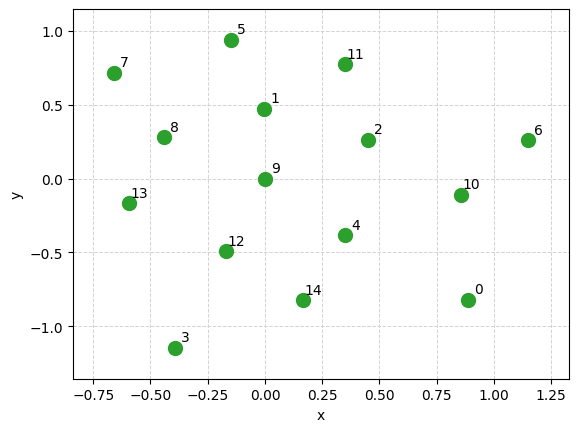

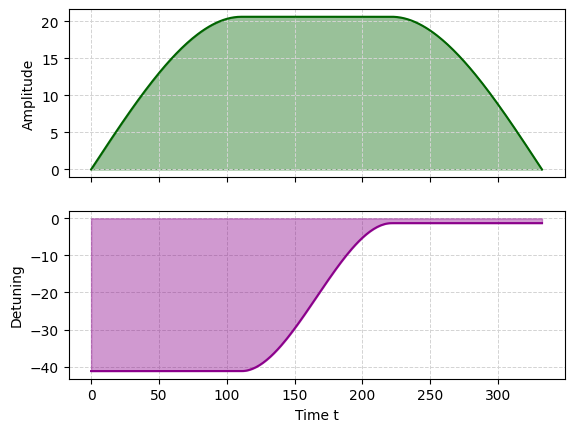

In [ ]:
%%seeded 1845417

import torch

from qubosolver import (
    Instance,
    Solution,
    solving,
    embedding,
    drive_shaping,
    matrix,
    LocalEmulator,
    analysis,
    transforms,
    matrix,
)
import qoolqit

Q = matrix.as_tensor(torch.load("qubo_size_15.pt", weights_only=True))
instance = Instance(Q)

device = qoolqit.AnalogDevice()
backend = LocalEmulator()

# Embed the QUBO instance and draw the register
register = embedding.blade.embed(instance)
register.draw()

# Drive-shaping and draw the drive
drive = drive_shaping.proportional_diagonal.build_drive(instance, register, device=device, kappa=0.5)
plt.figure()
drive.draw()

program = solving.analog_quantum_sampling.compile(register, drive, device)
job = backend.run(program)
solution = Solution.from_results(job.results(), instance)

print(analysis.to_dataframe([solution])[:20])


1. Define a `SolverConfig` to be passed to any solver

In [ ]:
config = SolverConfig()

For now, the `SolverConfig` contains parameters according to all available procedures (`pre-post processing`, `embedding`, ...). It has a default behavior that is compliant to the minimum requirements to run the workflow, as long as the given QUBO matrix fits with these default paremeters.

If one want to access to the default attributes, it is easily readable through the following:

In [ ]:
from dataclasses import asdict
from pprint import pprint
pprint(asdict(config), width=100)

{'activate_trivial_solutions': True,
 'config_name': '',
 'decompose': None,
 'postprocessing': False,
 'postprocessing_time_limit': inf,
 'preprocessing': False,
 'solving': {'backend': <qubosolver.types.backends.LocalEmulator object at 0x7b85cc065c00>,
             'device': AnalogDeviceWithDMM,
             'drive_shaping': {'algorithm': 'proportional_diagonal',
                               'bayesian_search_initial_detuning_parameters': [-0.8, 0.0, 0.8],
                               'bayesian_search_initial_omega_parameters': [0.5, 0.9, 0.5],
                               'bayesian_search_n_calls': 20,
                               'bayesian_search_seed': None,
                               'default_sequence_duration': 50000,
                               'dmm': True,
                               'local_energy_scale_kappa': 0.25,
                               'proportional_diagonal_kappa': 0.25},
             'embedding': {'algorithm': 'greedy_layout',
                   

2) Define a `Solver`, by passing the instance and the defined configuration

In [ ]:
# solver = Solver(instance, config)

3. Call the embedding method according to the provided set of parameters defined by the `SolverConfig`.

In [ ]:
# register = solver._embedding()

From the chosen embedding method, we get a set of two-dimensional coordinates that should be embeddable on the register:

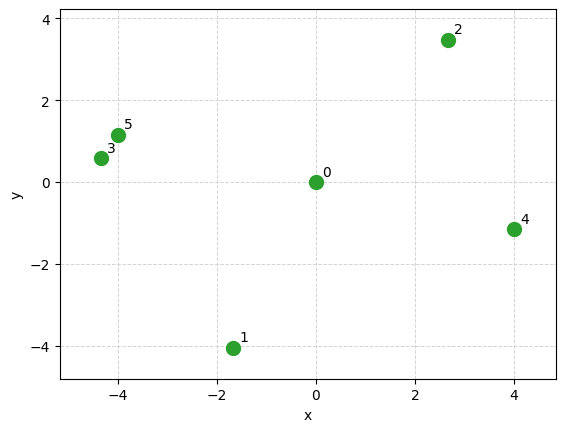

In [ ]:
# register.draw()

### BLaDE parametrization
Following previous workflow, we can reiterate using a more fined parametrization of the `SolverConfig` for the `blade` embedding method.

Here is a code snippet of an arbitrary parametrization of BLaDE using multiple layers of $n$-dimension and a number of steps per round (i.e. number of iteration per layer):

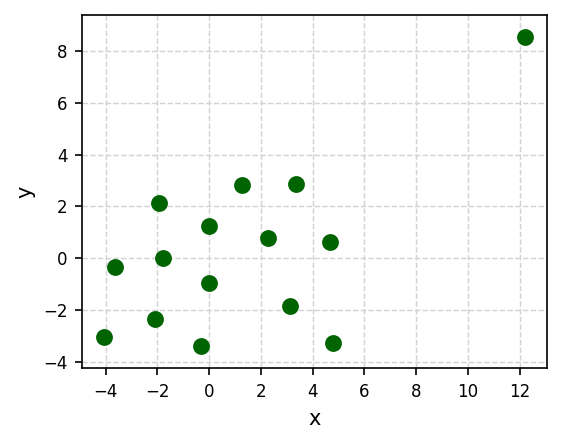

In [ ]:
# blade_settings = embedding.Config(algorithm="blade", blade_dimensions=[5 ,4, 3, 2], blade_steps_per_round=300)
# quantum_config = solvers.QuantumConfig(
#     device=AnalogDeviceWithDMM(),
#     embedding=blade_settings,
# )
# blade_config = solvers.Config(solving=quantum_config)

# solver = Solver(instance, blade_config)
# register = solver._embedding()
# register.draw()

### Greedy embedder parametrization
We do the same using the `greedy` embedding method, using a triangular lattice layout on a `AnalogDeviceWithDMM` with a number of greedy_traps at least equal to the number of variables in the QUBO (with `"device"` the number of traps is automatically set to the device capacity):

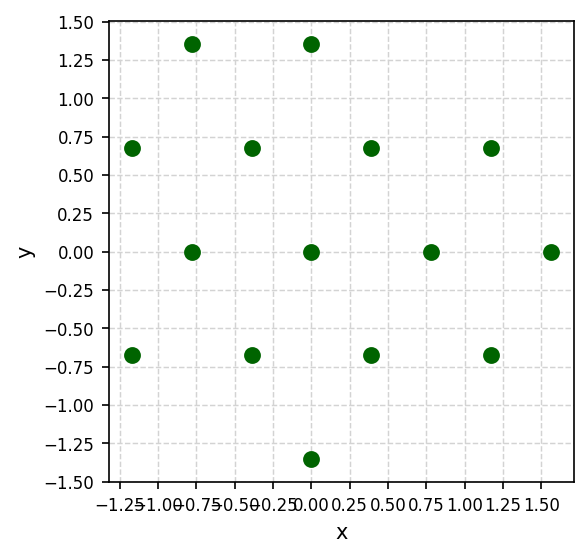

In [ ]:
# greedy_settings = embedding.Config(algorithm="greedy", greedy_layout="triangular", greedy_traps="device")

# quantum_config = solvers.QuantumConfig(
#     device=AnalogDeviceWithDMM(),
#     embedding=greedy_settings,
# )
# greedy_config = solvers.Config(solving=quantum_config)

# solver = Solver(instance, greedy_config)
# register = solver._embedding()
# register.draw()

### Custom embedder

If one desires to develop his own embedding method, a subclass of `qubosolver.pipeline.embedder.BaseEmbedder` should be implemented with a mandatory `embed` method.

The `embed` method `def embed(self) -> qoolqit.Register` specify how the problem is mapped into a register of qubits when running using a quantum device. Let us show a simple example where each variable $i$ is mapped into a qubit lying on a horizontal line (with coordinates $[i, 0]$, $i$ normalized by the device specs).

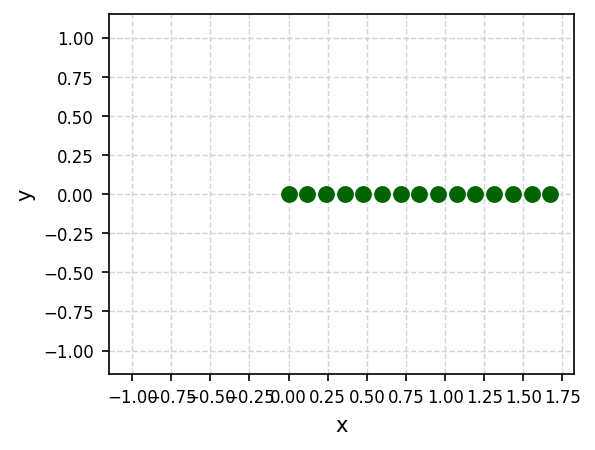

In [ ]:
# import typing
# from qubosolver import solvers
# from qubosolver.embedding._embedder import _BaseEmbedder
# from qoolqit import Register

# class FixedEmbedder(_BaseEmbedder):

#     @typing.no_type_check
#     def embed(self) -> Register:
#         qubits = {f"q{i}": (i,0) for i in range(self.instance.matrix.shape[0])}
#         register = Register(qubits)
#         return register


# custom_config = solvers.Config(
#     use_quantum=True,
#     embedding_method=FixedEmbedder,
# )
# solver = Solver(instance, custom_config)
# register = solver._embedding()
# register.draw()

# TODO: use the functional API